# Classical Localization: Triangulation

## Imports

In [1]:
from dataset_RT import training_set
import multiprocessing as mp
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy
import tqdm

2026-02-09 12:58:51.729307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770641931.751728    6532 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770641931.758598    6532 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770641931.776369    6532 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641931.776386    6532 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641931.776388    6532 computation_placer.cc:177] computation placer alr

## Load Data

### Load Array Positions and Determine Local Coordinate Systems

In [2]:
# RX positions
array_positions = np.load("dataset/array_positions.npy")
center_position = np.load("dataset/center_position.npy")

# RX directions
array_normalvectors = center_position - array_positions
array_normalvectors = array_normalvectors / np.linalg.norm(array_normalvectors, axis=1, keepdims=True)

# Find upvectors & rightvectors to span local coordinate system
# Constraint: rightvector is parallel to the x-y-plane
array_upvectors = np.zeros_like(array_normalvectors)
array_rightvectors = np.zeros_like(array_normalvectors)

# z-axis unit vector
z_axis_vector = np.array([0, 0, 1])

for i in range(len(array_positions)):
    normal_vector = array_normalvectors[i]
    # The rightvector is perpendicular to the normal vector and z-axis, found by the cross product.
    rightvector = np.cross(z_axis_vector, normal_vector)
    rightvector = rightvector / np.linalg.norm(rightvector)
    # The upvector is perpendicular to the normal vector and rightvector, found by the cross product.
    upvector = np.cross(normal_vector, rightvector)
    upvector = upvector / np.linalg.norm(upvector)
    # Store the vectors
    array_rightvectors[i] = rightvector
    array_upvectors[i] = upvector

# Rotation matrices for each array
rot = np.stack([-array_rightvectors, array_normalvectors, array_upvectors], axis=-1)

### Load UE Positions

In [3]:
# Load groundtruth positions
groundtruth_positions = []
for csi, pos in training_set.batch(1000):
    groundtruth_positions.append(pos.numpy())

groundtruth_positions = np.concatenate(groundtruth_positions)

# Count number of datapoints in training set (for progress bar)
TOTAL_DATAPOINTS = len(groundtruth_positions)

2026-02-09 12:58:55.231760: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-09 12:58:57.103325: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Load estimated AoAs and Delay Spreads

In [4]:
estimated_aoas_azimuth = np.load("results/estimated_aoas_azimuth.npy")
estimated_aoas_elevation = np.load("results/estimated_aoas_elevation.npy")
delayspreads = np.load("results/delayspreads.npy")

assert(len(estimated_aoas_azimuth) == TOTAL_DATAPOINTS)
assert(len(estimated_aoas_elevation) == TOTAL_DATAPOINTS)
assert(len(delayspreads) == TOTAL_DATAPOINTS)

## Estimate UE Positions based on AoAs

In [5]:
# These are some empirically determined heuristics, may be further tweaked
def get_aoa_vonmises_kappas(delayspreads):
    return 0.0000001 / (delayspreads + 0.025e-7)

# Generate AoA-based likelihood function.
def get_likelihood_function(aoa_az_datapoint, aoa_el_datapoint, rms_delay_spreads):

    aoa_az_datapoint = -aoa_az_datapoint
    aoa_el_datapoint = -aoa_el_datapoint
    
    def likelihood_func(parameters):
        
        # "relative_pos" has shape (number of positions, number of arrays, 3 spatial dimensions)
        relative_pos = parameters[:,np.newaxis,:3] - array_positions

        # Normalized direction vectors of relative_pos in global coordinate frame
        # Shape (number of positions, number of arrays, 3 spatial dimensions)
        normalized_direction_vector_global = relative_pos / np.linalg.norm(relative_pos, axis=2, keepdims=True)

        # Unit direction vector in local coordinates of the respective arrays based on the estimated AoAs
        # Shape aoas (4)
        # Shape direction_vector (4,3)
        estimated_unit_direction_vector_local = np.array([np.cos(aoa_el_datapoint)*np.sin(aoa_az_datapoint),
                                                          np.cos(aoa_el_datapoint)*np.cos(aoa_az_datapoint),
                                                          np.sin(aoa_el_datapoint)]).T
        # Transform vector into global coordinates
        estimated_unit_direction_vector_global = np.einsum('bij,bj->bi', rot, estimated_unit_direction_vector_local)

        # Dot product between the two direction vectors
        dot_products = np.einsum('lbi,bi->lb', normalized_direction_vector_global, estimated_unit_direction_vector_global)

        # Compute AoA likelihoods based on von Mises distribution
        kappa = get_aoa_vonmises_kappas(rms_delay_spreads)
        aoa_likelihoods = np.expand_dims((kappa / (4*np.pi*np.sinh(kappa))), axis=0) * np.exp( np.expand_dims(kappa, axis=0) * dot_products )

        return np.prod(aoa_likelihoods, axis = -1)

    return likelihood_func

In [6]:
# Generate grid of potential TX positions, used for initializing optimization algorithm
candidate_xrange = np.linspace(np.min(array_positions[:,0]) - 2, np.max(array_positions[:,0]) + 2, 20)
candidate_yrange = np.linspace(np.min(array_positions[:,1]) - 2, np.max(array_positions[:,1]) + 2, 20)
candidate_zrange = np.linspace(1, 9, 20)

# 3D mesh grid
candidate_initial_positions = np.transpose(np.meshgrid(candidate_xrange, candidate_yrange, candidate_zrange)).reshape(-1, 3)

def aoa_estimation_worker(todo_queue, output_queue):
    def estimate_position_aoa(index):
        aoa_az_datapoint = estimated_aoas_azimuth[index]
        aoa_el_datapoint = estimated_aoas_elevation[index]
        ds_datapoint = delayspreads[index]
    
        # Find most likely initialization position based on AoA
        likelihood_func = get_likelihood_function(aoa_az_datapoint, aoa_el_datapoint, ds_datapoint)
        initial_point = candidate_initial_positions[np.argmax(likelihood_func(candidate_initial_positions))]

        # Use scipy.optimize to find most likely TX position
        init_value = np.asarray([initial_point[0], initial_point[1], initial_point[2]])
        optimize_res = scipy.optimize.minimize(lambda pos_and_time : -likelihood_func(np.asarray([[pos_and_time[0], pos_and_time[1], pos_and_time[2]]])), init_value, options = {"gtol": 1e-7})

        return np.asarray([optimize_res.x[0], optimize_res.x[1], optimize_res.x[2]]), -optimize_res.fun
    
    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None, None))
            break

        position, likelihood = estimate_position_aoa(index)
        output_queue.put((index, position, likelihood))

In [7]:
# Run AoA-based estimation in parallel across multiple processes
todo_queue = mp.Queue()
output_queue = mp.Queue()

for i in zip(range(TOTAL_DATAPOINTS)):
    todo_queue.put(i)

for i in range(mp.cpu_count()):
    todo_queue.put(-1)
    p = mp.Process(target = aoa_estimation_worker, args = (todo_queue, output_queue))
    p.start()

estimated_positions = np.zeros((TOTAL_DATAPOINTS, 3))

with tqdm.tqdm(total = TOTAL_DATAPOINTS) as bar:
    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, pos, lik = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            estimated_positions[i,:] = pos
            bar.update(1)

100%|██████████| 5000/5000 [00:11<00:00, 425.03it/s]


## Save Position Estimates as NumPy

In [8]:
# Save estimated positions
np.save("results/classical_positions.npy", estimated_positions)

## Optional: Evaluate Accuracy of Posiiton Estimates

### Visualize Position Estimates

In [9]:
%matplotlib widget 

def plot_colorized(positions, groundtruth_positions, title = None, alpha = 1.0, save_path = None):
    # Generate RGB colors for datapoints
    center_point = np.zeros(3, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    center_point[2] = 0.5 * (np.min(groundtruth_positions[:, 2], axis = 0) + np.max(groundtruth_positions[:, 2], axis = 0))
    NormalizeData = lambda in_data : (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 2])

    # Plot datapoints
    ax = plt.figure(figsize=(7,6)).add_subplot(projection='3d')
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c = rgb_values, s = 5, alpha = alpha, linewidths = 3)

    ax.scatter(array_positions[:,0], array_positions[:,1], array_positions[:,2], marker = 's', s = 7, c = 'black', alpha = 1, linewidth = 5)
    
    ax.set_zlim(0,11)
    ax.set_xlabel('x-coordinate $[m]$')
    ax.set_ylabel('y-coordinate $[m]$')
    ax.set_zlabel('z-coordinate $[m]$')

    ax.set_box_aspect([np.ptp(groundtruth_positions[:, 0]), np.ptp(groundtruth_positions[:, 1]), 1.5*np.ptp(groundtruth_positions[:, 2])])
    
    # Customize the view angle so it's easier to see that the scatter points lie
    # on the plane y=0
    ax.view_init(elev=40., azim=125, roll=0)
    plt.tight_layout()
    plt.subplots_adjust(left=-0.05, right=0.95, top=1.0, bottom=0.05)
    if save_path is not None:
        plt.savefig(save_path, dpi=600)
    plt.show()

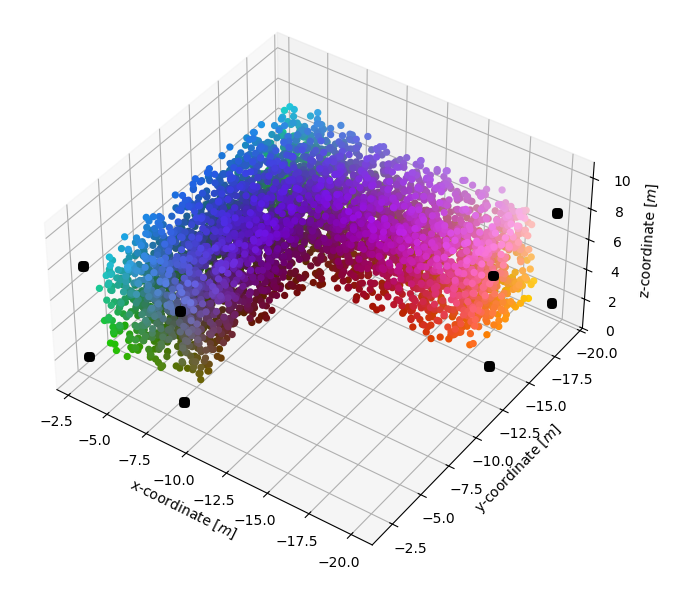

In [10]:
# Groundtruth positions
plot_colorized(groundtruth_positions, groundtruth_positions)

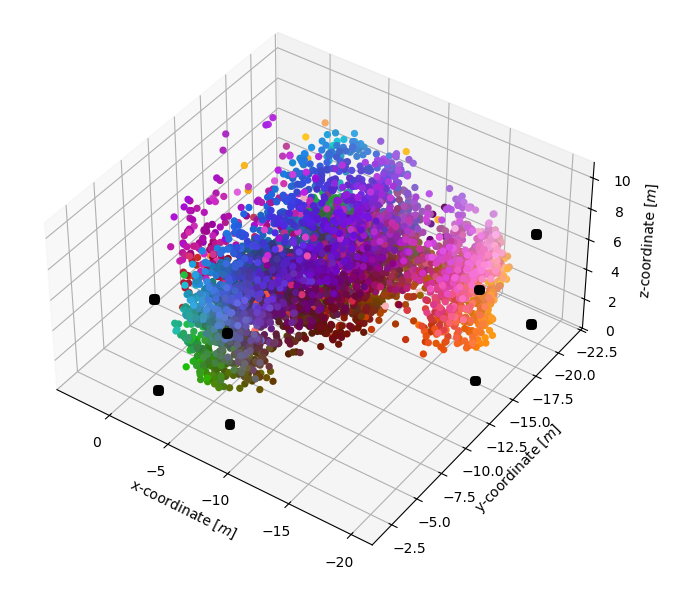

In [11]:
# Estimated positions
plot_colorized(estimated_positions, groundtruth_positions, save_path = "results/classical_positions.png")

### Error CDF

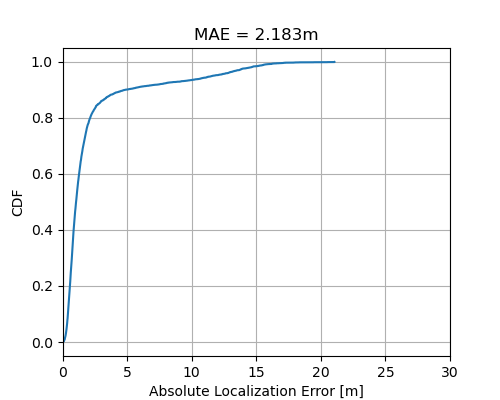

In [12]:
# Quantitative evaluation of localization error
position_errors = estimated_positions[:,:3] - groundtruth_positions[:len(estimated_positions),:3]
absolute_errors = np.sqrt(np.sum(np.square(position_errors), axis = 1))

count, bins_count = np.histogram(absolute_errors, bins=5000)
pdf = count / sum(count)
cdf = np.cumsum(pdf)

bins_count[0] = 0
cdf = np.append([0], cdf)

plt.figure(figsize=(5, 4))
plt.title("MAE = " + f"{(np.mean(absolute_errors)):.3f}m")
plt.plot(bins_count, cdf)
plt.xlim((0, 30))
plt.xlabel("Absolute Localization Error [m]")
plt.ylabel("CDF")
plt.grid()
plt.show()